In [1]:
import joblib
import numpy as np
import cv2
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import regionprops, label as sk_label
import mahotas
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Paths
PROC = Path('../data/processed')
RAW = Path('../data/raw')
MODELS = Path('../models')

# Load all three models
print("Loading saved models...")
rad_bundle = joblib.load(MODELS / 'radiomics.pkl')
deep_bundle = joblib.load(MODELS / 'deep.pkl')
fused_bundle = joblib.load(MODELS / 'fused.pkl')

print(f"  Radiomics-only model loaded ({len(rad_bundle['cols'])} features)")
print(f"  Deep-only model loaded ({len(deep_bundle['cols'])} features)")
print(f"  Fused model loaded ({len(fused_bundle['selected_names'])} selected features)")

# Class labels (must match the LabelEncoder order from training)
CLASS_NAMES = ['glioma', 'meningioma', 'notumor', 'pituitary']
print(f"\nClass labels: {CLASS_NAMES}")

Loading saved models...
  Radiomics-only model loaded (47 features)
  Deep-only model loaded (2048 features)
  Fused model loaded (300 selected features)

Class labels: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [2]:
# Load frozen ResNet50
print("Loading ResNet50...")
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Identity()
resnet.eval()
for p in resnet.parameters():
    p.requires_grad = False

# Same preprocessing as Day 5
deep_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print("ResNet50 ready (frozen, eval mode)")

Loading ResNet50...
ResNet50 ready (frozen, eval mode)


In [3]:
# ============================================================
# PREPROCESSING (from Day 2)
# ============================================================
def crop_brain(img_gray):
    _, thresh = cv2.threshold(img_gray, 10, 255, cv2.THRESH_BINARY)
    thresh = cv2.dilate(thresh, None, iterations=2)
    thresh = cv2.erode(thresh, None, iterations=2)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return img_gray
    biggest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(biggest)
    pad = 5
    h_img, w_img = img_gray.shape
    return img_gray[max(0, y-pad):min(h_img, y+h+pad), max(0, x-pad):min(w_img, x+w+pad)]

def preprocess_image(img_path, size=224):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    img = crop_brain(img)
    img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    return clahe.apply(img)

# ============================================================
# MASK (from Day 3)
# ============================================================
def make_brain_mask(img_gray):
    _, mask = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel_big = np.ones((11, 11), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big, iterations=3)
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels <= 1: return np.ones_like(img_gray, dtype=np.uint8)
    largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    brain_mask = (labels == largest).astype(np.uint8)
    brain_mask = cv2.morphologyEx(brain_mask, cv2.MORPH_CLOSE, kernel_big, iterations=2)
    brain_mask_filled = brain_mask.copy()
    contours, _ = cv2.findContours(brain_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cv2.drawContours(brain_mask_filled, contours, -1, 1, thickness=cv2.FILLED)
    return brain_mask_filled

# ============================================================
# RADIOMICS FEATURES (from Day 4)
# ============================================================
def extract_first_order(img, mask):
    pixels = img[mask > 0].astype(np.float64)
    if len(pixels) == 0:
        return {f'fo_{k}': 0.0 for k in ['mean','std','min','max','median','p10','p90',
                                          'skew','kurt','energy','entropy','range','iqr']}
    p10, p25, p50, p75, p90 = np.percentile(pixels, [10,25,50,75,90])
    mean = pixels.mean(); std = pixels.std() + 1e-9
    skew = ((pixels-mean)**3).mean() / (std**3)
    kurt = ((pixels-mean)**4).mean() / (std**4) - 3
    hist, _ = np.histogram(pixels, bins=64, range=(0,256), density=True)
    hist = hist[hist > 0]
    entropy = -np.sum(hist * np.log2(hist))
    return {'fo_mean':float(mean),'fo_std':float(pixels.std()),'fo_min':float(pixels.min()),
            'fo_max':float(pixels.max()),'fo_median':float(p50),'fo_p10':float(p10),
            'fo_p90':float(p90),'fo_skew':float(skew),'fo_kurt':float(kurt),
            'fo_energy':float((pixels**2).sum()/1e6),'fo_entropy':float(entropy),
            'fo_range':float(pixels.max()-pixels.min()),'fo_iqr':float(p75-p25)}

def extract_glcm(img, mask, levels=32):
    img_q = (img.astype(np.float32) * (levels-1) / 255).astype(np.uint8)
    img_q = np.where(mask > 0, img_q, 0)
    glcm = graycomatrix(img_q, distances=[1,3], angles=[0,np.pi/4,np.pi/2,3*np.pi/4],
                         levels=levels, symmetric=True, normed=True)
    feats = {}
    for prop in ['contrast','homogeneity','energy','correlation','dissimilarity','ASM']:
        vals = graycoprops(glcm, prop)
        feats[f'glcm_{prop}_mean'] = float(vals.mean())
        feats[f'glcm_{prop}_std']  = float(vals.std())
    return feats

def extract_haralick(img, mask):
    img_masked = np.where(mask > 0, img, 0).astype(np.uint8)
    try:
        h = mahotas.features.haralick(img_masked, ignore_zeros=True, return_mean=True)
    except Exception:
        h = np.zeros(13)
    names = ['angular_2nd_moment','contrast','correlation','sum_of_squares','inverse_diff_moment',
            'sum_avg','sum_variance','sum_entropy','entropy','difference_variance',
            'difference_entropy','info_correlation_1','info_correlation_2']
    return {f'har_{n}': float(v) for n, v in zip(names, h)}

def extract_shape(mask):
    mask_bin = (mask > 0).astype(np.uint8)
    labels = sk_label(mask_bin)
    if labels.max() == 0:
        return {f'sh_{k}': 0.0 for k in ['area','perimeter','eccentricity','solidity',
                                          'extent','major_axis','minor_axis','circularity','aspect_ratio']}
    region = max(regionprops(labels), key=lambda r: r.area)
    perim = region.perimeter + 1e-9
    circularity = 4 * np.pi * region.area / (perim**2)
    aspect = region.major_axis_length / (region.minor_axis_length + 1e-9)
    return {'sh_area':float(region.area),'sh_perimeter':float(region.perimeter),
            'sh_eccentricity':float(region.eccentricity),'sh_solidity':float(region.solidity),
            'sh_extent':float(region.extent),'sh_major_axis':float(region.major_axis_length),
            'sh_minor_axis':float(region.minor_axis_length),'sh_circularity':float(circularity),
            'sh_aspect_ratio':float(aspect)}

def extract_radiomics(img, mask):
    feats = {}
    feats.update(extract_first_order(img, mask))
    feats.update(extract_glcm(img, mask))
    feats.update(extract_haralick(img, mask))
    feats.update(extract_shape(mask))
    return feats

# ============================================================
# DEEP FEATURES (from Day 5)
# ============================================================
def extract_deep(img):
    pil_img = Image.fromarray(img).convert('L')
    tensor = deep_preprocess(pil_img).unsqueeze(0)
    with torch.no_grad():
        feats = resnet(tensor).cpu().numpy().flatten()
    return feats

print("All functions defined")

All functions defined


In [5]:
def predict_one(img_path, show_plot=True):
    """
    Full pipeline: image path → prediction with visualization.
    Returns dict with predictions from all three models.
    """
    img_path = Path(img_path)
    
    # 1. Preprocess
    proc_img = preprocess_image(img_path)
    if proc_img is None:
        print(f"Could not read image: {img_path}")
        return None
    
    # 2. Generate mask
    mask = make_brain_mask(proc_img)
    
    # 3. Extract features
    rad_feats = extract_radiomics(proc_img, mask)
    deep_feats_arr = extract_deep(proc_img)
    
    # 4. Build feature vectors in correct order
    rad_vec = np.array([rad_feats[c] for c in rad_bundle['cols']]).reshape(1, -1)
    deep_vec = deep_feats_arr.reshape(1, -1)
    fused_vec = np.concatenate([rad_vec, deep_vec], axis=1)
    
    # 5. Apply scalers and selectors
    rad_scaled = rad_bundle['scaler'].transform(rad_vec)
    deep_scaled = deep_bundle['scaler'].transform(deep_vec)
    fused_scaled = fused_bundle['scaler'].transform(fused_vec)
    fused_selected = fused_bundle['selector'].transform(fused_scaled)
    
    # 6. Predict with all 3 models
    rad_pred_idx = rad_bundle['clf'].predict(rad_scaled)[0]
    rad_proba = rad_bundle['clf'].predict_proba(rad_scaled)[0]
    
    deep_pred_idx = deep_bundle['clf'].predict(deep_scaled)[0]
    deep_proba = deep_bundle['clf'].predict_proba(deep_scaled)[0]
    
    fused_pred_idx = fused_bundle['clf'].predict(fused_selected)[0]
    fused_proba = fused_bundle['clf'].predict_proba(fused_selected)[0]
    
    results = {
        'image_path': str(img_path),
        'radiomics': {'pred': CLASS_NAMES[rad_pred_idx], 'proba': dict(zip(CLASS_NAMES, rad_proba))},
        'deep':      {'pred': CLASS_NAMES[deep_pred_idx], 'proba': dict(zip(CLASS_NAMES, deep_proba))},
        'fused':     {'pred': CLASS_NAMES[fused_pred_idx], 'proba': dict(zip(CLASS_NAMES, fused_proba))},
    }
    
    # 7. Visualize
    if show_plot:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        original = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        axes[0].imshow(original, cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
        axes[1].imshow(proc_img, cmap='gray'); axes[1].set_title("Preprocessed (224×224, CLAHE)"); axes[1].axis('off')
        
        # Bar chart of fused model probabilities
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
        axes[2].bar(CLASS_NAMES, fused_proba, color=colors)
        axes[2].set_title(f"Fused model prediction:\n{CLASS_NAMES[fused_pred_idx].upper()} (confidence: {fused_proba[fused_pred_idx]:.2%})")
        axes[2].set_ylim(0, 1)
        axes[2].set_ylabel('Probability')
        axes[2].grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Print all 3 model results
        print("\n" + "=" * 60)
        print(f"All 3 models say:")
        print("=" * 60)
        print(f"  Radiomics-only: {results['radiomics']['pred']:12s} (confidence: {max(rad_proba):.2%})")
        print(f"  Deep-only:      {results['deep']['pred']:12s} (confidence: {max(deep_proba):.2%})")
        print(f"  Fused (final):  {results['fused']['pred']:12s} (confidence: {max(fused_proba):.2%})")
    
    return results

In [6]:
import random
random.seed(42)

# Pick one image per class from the test set
demo_images = {}
for c in CLASS_NAMES:
    files = list((RAW / 'Testing' / c).glob('*'))
    if files:
        demo_images[c] = random.choice(files)
        print(f"{c:12s} → {demo_images[c].name}")

print(f"\n{len(demo_images)} demo images selected.")

glioma       → Te-gl_394.jpg
meningioma   → Te-aug-me_58.jpg
notumor      → Te-no_11.jpg
pituitary    → Te-pi_80.jpg

4 demo images selected.


DEMO 1: True class = glioma


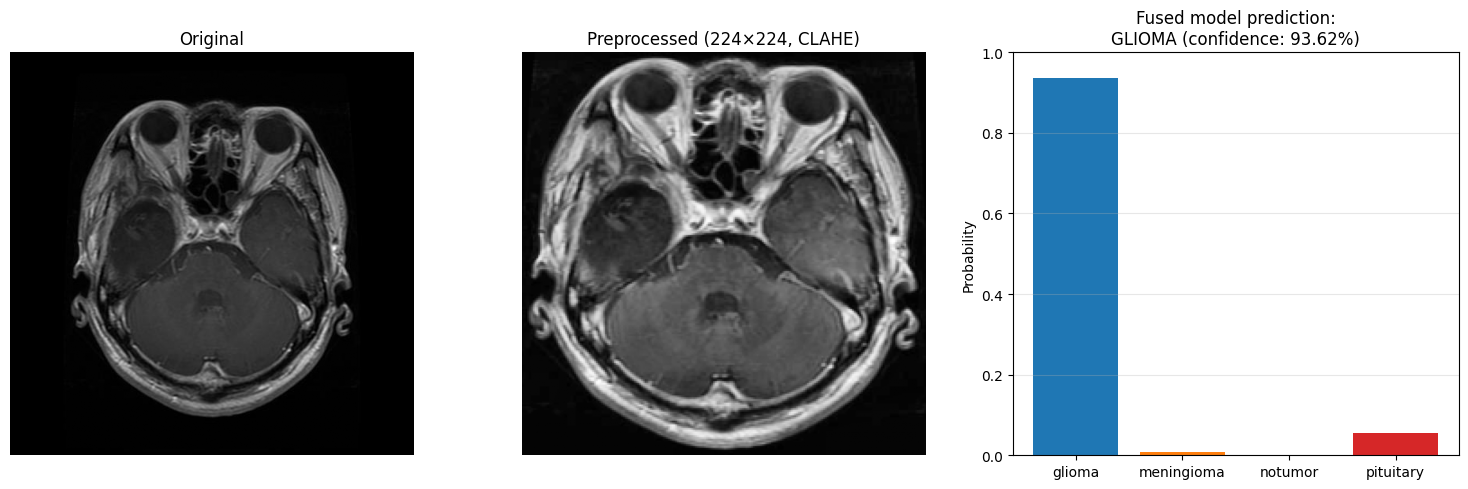


All 3 models say:
  Radiomics-only: glioma       (confidence: 99.06%)
  Deep-only:      pituitary    (confidence: 55.34%)
  Fused (final):  glioma       (confidence: 93.62%)


In [7]:
print("=" * 60)
print(f"DEMO 1: True class = glioma")
print("=" * 60)
result = predict_one(demo_images['glioma'])

DEMO 2: True class = meningioma


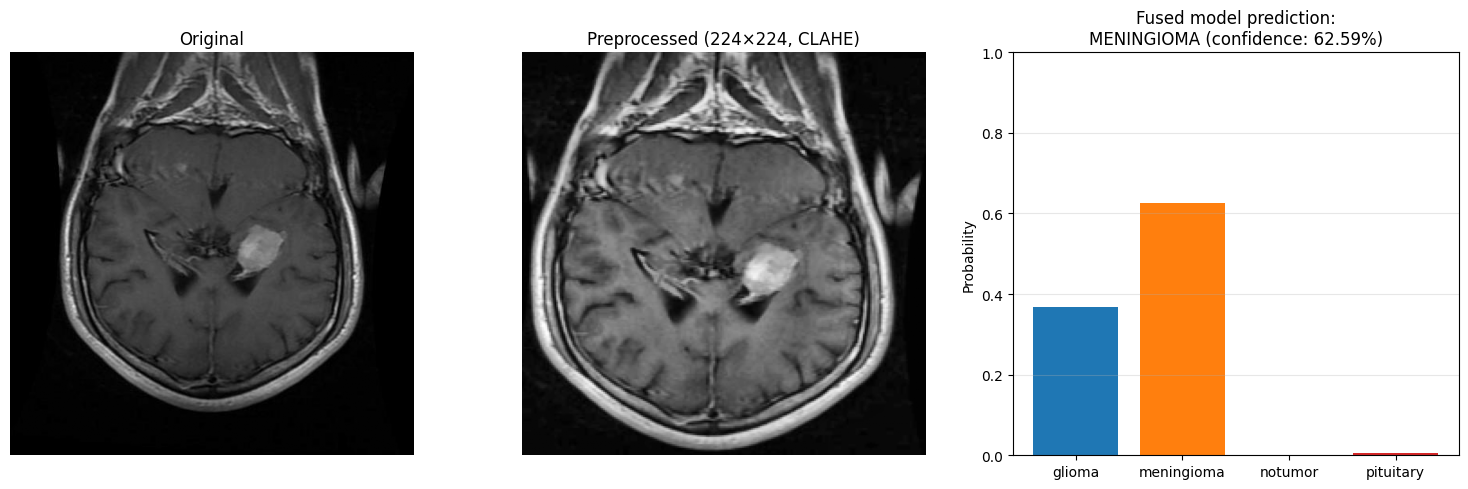


All 3 models say:
  Radiomics-only: meningioma   (confidence: 73.48%)
  Deep-only:      meningioma   (confidence: 93.09%)
  Fused (final):  meningioma   (confidence: 62.59%)


In [8]:
print("=" * 60)
print(f"DEMO 2: True class = meningioma")
print("=" * 60)
result = predict_one(demo_images['meningioma'])

DEMO 3: True class = pituitary


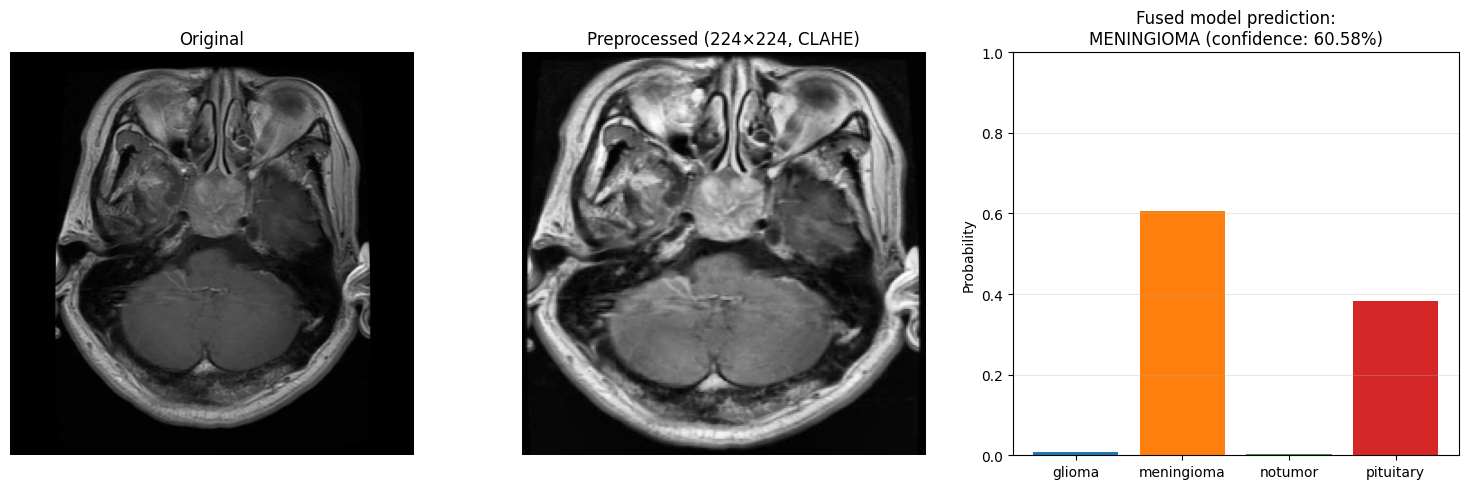


All 3 models say:
  Radiomics-only: pituitary    (confidence: 91.57%)
  Deep-only:      pituitary    (confidence: 52.88%)
  Fused (final):  meningioma   (confidence: 60.58%)


In [9]:
print("=" * 60)
print(f"DEMO 3: True class = pituitary")
print("=" * 60)
result = predict_one(demo_images['pituitary'])

DEMO 4: True class = notumor


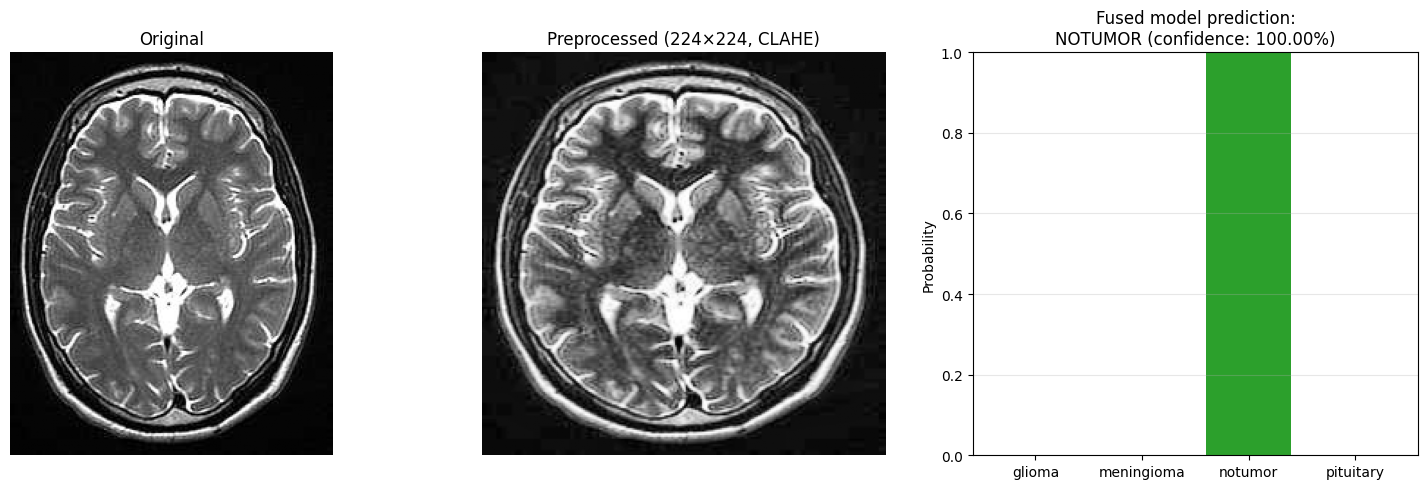


All 3 models say:
  Radiomics-only: notumor      (confidence: 99.99%)
  Deep-only:      notumor      (confidence: 99.99%)
  Fused (final):  notumor      (confidence: 100.00%)


In [10]:
print("=" * 60)
print(f"DEMO 4: True class = notumor")
print("=" * 60)
result = predict_one(demo_images['notumor'])

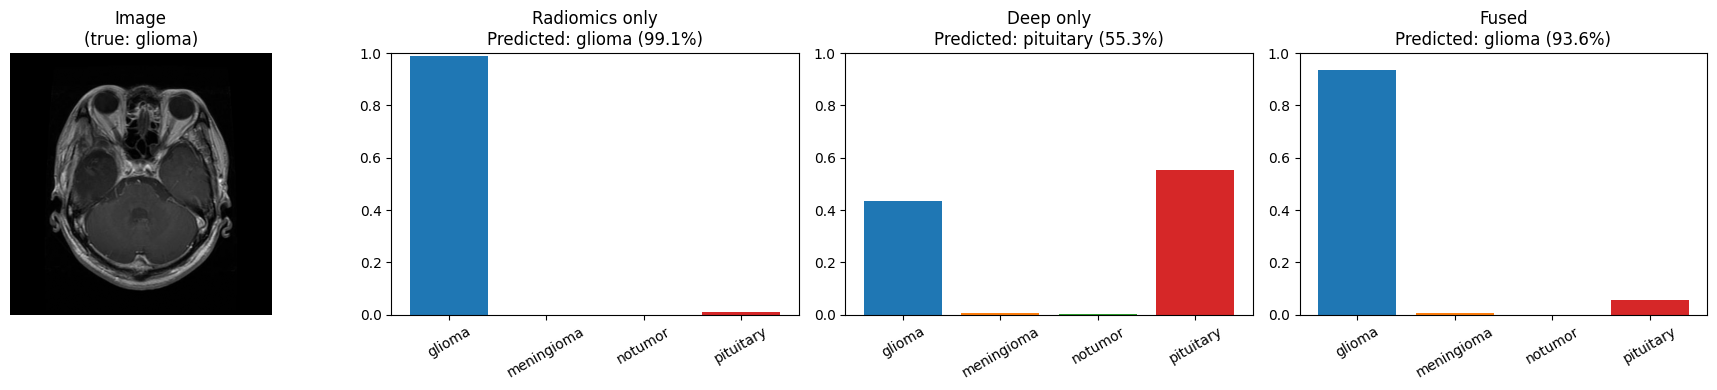

In [11]:
def compare_models_visual(img_path):
    img_path = Path(img_path)
    result = predict_one(img_path, show_plot=False)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    
    original = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title(f"Image\n(true: {img_path.parent.name})")
    axes[0].axis('off')
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for idx, (model_name, label) in enumerate([('radiomics', 'Radiomics only'),
                                                ('deep', 'Deep only'),
                                                ('fused', 'Fused')]):
        probs = [result[model_name]['proba'][c] for c in CLASS_NAMES]
        pred = result[model_name]['pred']
        confidence = max(probs)
        
        axes[idx+1].bar(CLASS_NAMES, probs, color=colors)
        axes[idx+1].set_title(f"{label}\nPredicted: {pred} ({confidence:.1%})")
        axes[idx+1].set_ylim(0, 1)
        axes[idx+1].tick_params(axis='x', rotation=30)
    
    plt.tight_layout()
    plt.savefig(f'../outputs/demo_3model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

# Run it on the glioma demo image — most interesting for showing class disagreement
compare_models_visual(demo_images['glioma'])